In [34]:
# 导入必要的库
import os 
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
import time
import warnings
warnings.filterwarnings("ignore")
import copy
from PIL import Image
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# 设置matplotlib中文支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 检查GPU是否可用
train_on_gpu = torch.cuda.is_available()
if train_on_gpu:
    print('使用GPU训练')
else:
    print('使用CPU训练（已针对CPU优化）')
device = torch.device('cuda:0' if train_on_gpu else 'cpu')

使用CPU训练（已针对CPU优化）


# 第一阶段：多模型对比实验
## 1.1 数据分割（8:1:1）

In [11]:
# 原始数据路径
data_dir = r'F:\药材识别\data'

# 目标路径（用于存放分割后的数据）
output_dir = r'F:\药材识别\split_data'
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

# 创建目标文件夹
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# 获取所有类别
categories = [cat for cat in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cat))]

# 遍历每个类别
for category in categories:
    cat_path = os.path.join(data_dir, category)
    images = [img for img in os.listdir(cat_path) if img.lower().endswith(('.png', '.jpg', '.jpeg', '.gif'))]
    
    # 第一次分割：80% 训练集，20% 剩余
    train_imgs, temp_imgs = train_test_split(images, test_size=0.2, random_state=42)
    
    # 第二次分割：10% 验证集，10% 测试集
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)
    
    # 创建类别子文件夹
    for folder in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(folder, category), exist_ok=True)
    
    # 复制图片
    for img in train_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(train_dir, category, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(val_dir, category, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cat_path, img), os.path.join(test_dir, category, img))
    
    print(f'类别 {category}: 训练集 {len(train_imgs)} 张, 验证集 {len(val_imgs)} 张, 测试集 {len(test_imgs)} 张')

print('\n数据分割完成！')

类别 baihe: 训练集 144 张, 验证集 18 张, 测试集 18 张
类别 dangshen: 训练集 152 张, 验证集 19 张, 测试集 19 张
类别 gouqi: 训练集 148 张, 验证集 18 张, 测试集 19 张
类别 huaihua: 训练集 133 张, 验证集 17 张, 测试集 17 张
类别 jinyinhua: 训练集 144 张, 验证集 18 张, 测试集 18 张

数据分割完成！


## 1.2 数据预处理（CPU优化版）

In [12]:
# 数据预处理
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# 批次大小（CPU优化）
batch_size = 8

# 创建数据集
image_datasets = {
    'train': ImageFolder(os.path.join(output_dir, 'train'), data_transforms['train']),
    'val': ImageFolder(os.path.join(output_dir, 'val'), data_transforms['val']),
    'test': ImageFolder(os.path.join(output_dir, 'test'), data_transforms['test'])
}

# 创建数据加载器
data_loaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=False),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False)
}

# 获取数据集大小和类别
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f'训练集: {dataset_sizes["train"]}, 验证集: {dataset_sizes["val"]}, 测试集: {dataset_sizes["test"]}')
print(f'类别: {class_names}')

训练集: 721, 验证集: 90, 测试集: 91
类别: ['baihe', 'dangshen', 'gouqi', 'huaihua', 'jinyinhua']


## 1.3 定义多模型初始化函数

In [13]:
def set_parameter_requires_grad(model, feature_extract):
    if feature_extract:
        for param in model.parameters():
            param.requires_grad = False


def get_model(model_name, num_classes, feature_extract=True, use_pretrained=True):
    """获取指定的预训练模型"""
    
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=use_pretrained)
        set_parameter_requires_grad(model, feature_extract)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=use_pretrained)
        set_parameter_requires_grad(model, feature_extract)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(pretrained=use_pretrained)
        set_parameter_requires_grad(model, feature_extract)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=use_pretrained)
        set_parameter_requires_grad(model, feature_extract)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        
    else:
        raise ValueError(f'不支持的模型: {model_name}')
    
    return model


def get_model_params(model):
    """获取模型的参数量"""
    return sum(p.numel() for p in model.parameters()) / 1e6


# 定义要对比的模型列表
models_to_compare = ['resnet18', 'resnet50', 'mobilenet_v2', 'efficientnet_b0']

print('支持的模型:')
for name in models_to_compare:
    print(f'  - {name}')

支持的模型:
  - resnet18
  - resnet50
  - mobilenet_v2
  - efficientnet_b0


## 1.4 统一训练函数

In [14]:
def train_single_model(model_name, data_loaders, dataset_sizes, device, 
                       num_classes, feature_extract=True, 
                       num_epochs_stage1=15, num_epochs_stage2=10, 
                       patience=5, verbose=True):
    """训练单个模型，返回训练结果"""
    
    if verbose:
        print(f'\n{"="*60}')
        print(f'开始训练模型: {model_name}')
        print(f'{"="*60}')
    
    start_time = time.time()
    
    # 阶段1：冻结特征层，只训练分类层
    if verbose:
        print(f'\n阶段1: 冻结特征层，训练分类层')
    
    model = get_model(model_name, num_classes, feature_extract=True)
    model = model.to(device)
    
    # 获取待训练参数
    params_to_update = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            params_to_update.append(param)
    
    optimizer = optim.Adam(params_to_update, lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_stage1, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    
    # 训练阶段1
    best_acc_stage1 = 0.0
    best_model_wts_stage1 = copy.deepcopy(model.state_dict())
    no_improve_count = 0
    
    for epoch in range(num_epochs_stage1):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in data_loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            if phase == 'val' and epoch_acc > best_acc_stage1:
                best_acc_stage1 = epoch_acc
                best_model_wts_stage1 = copy.deepcopy(model.state_dict())
                no_improve_count = 0
            elif phase == 'val':
                no_improve_count += 1
        
        scheduler.step()
        
        if verbose and (epoch + 1) % 3 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs_stage1}, Val Acc: {best_acc_stage1:.4f}')
        
        if no_improve_count >= patience:
            if verbose:
                print(f'  阶段1早停，epoch {epoch+1}')
            break
    
    # 阶段2：解冻全部层，微调
    if verbose:
        print(f'\n阶段2: 解冻全部层，微调模型')
    
    # 解冻所有层
    for param in model.parameters():
        param.requires_grad = True
    
    model.load_state_dict(best_model_wts_stage1)
    
    optimizer_ft = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=num_epochs_stage2, eta_min=1e-6)
    
    # 训练阶段2
    best_acc = best_acc_stage1
    best_model_wts = copy.deepcopy(best_model_wts_stage1)
    no_improve_count = 0
    
    for epoch in range(num_epochs_stage2):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in data_loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer_ft.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    if phase == 'train':
                        loss.backward()
                        optimizer_ft.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                no_improve_count = 0
            elif phase == 'val':
                no_improve_count += 1
        
        scheduler_ft.step()
        
        if verbose and (epoch + 1) % 3 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs_stage2}, Val Acc: {best_acc:.4f}')
        
        if no_improve_count >= patience:
            if verbose:
                print(f'  阶段2早停，epoch {epoch+1}')
            break
    
    # 加载最佳模型
    model.load_state_dict(best_model_wts)
    
    # 在测试集上评估
    model.eval()
    test_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in data_loaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels.data)
    
    test_acc = test_corrects.double() / dataset_sizes['test']
    
    total_time = time.time() - start_time
    
    if verbose:
        print(f'\n{model_name} 训练完成:')
        print(f'  最佳验证准确率: {best_acc:.4f}')
        print(f'  测试准确率: {test_acc:.4f}')
        print(f'  总耗时: {total_time/60:.1f}分钟')
    
    return {
        'model_name': model_name,
        'best_val_acc': best_acc.item() if torch.is_tensor(best_acc) else best_acc,
        'test_acc': test_acc.item() if torch.is_tensor(test_acc) else test_acc,
        'params_M': get_model_params(model),
        'training_time_min': total_time / 60,
        'model': model,
        'best_model_wts': best_model_wts
    }

## 1.5 多模型对比实验

In [15]:
# 存储所有模型的训练结果
all_results = []
trained_models = {}

# 依次训练每个模型
for model_name in models_to_compare:
    result = train_single_model(
        model_name=model_name,
        data_loaders=data_loaders,
        dataset_sizes=dataset_sizes,
        device=device,
        num_classes=len(class_names),
        feature_extract=True,
        num_epochs_stage1=15,
        num_epochs_stage2=10,
        patience=5,
        verbose=True
    )
    
    # 保存模型权重
    torch.save(result['best_model_wts'], f'{model_name}_final.pth')
    
    trained_models[model_name] = result['model']
    all_results.append({
        '模型': model_name,
        '参数量(M)': result['params_M'],
        '验证准确率': result['best_val_acc'],
        '测试准确率': result['test_acc'],
        '训练时间(分钟)': result['training_time_min']
    })

print('\n所有模型训练完成！')


开始训练模型: resnet18

阶段1: 冻结特征层，训练分类层
  Epoch 3/15, Val Acc: 0.8556
  Epoch 6/15, Val Acc: 0.9222
  Epoch 9/15, Val Acc: 0.9333
  Epoch 12/15, Val Acc: 0.9333
  阶段1早停，epoch 12

阶段2: 解冻全部层，微调模型
  Epoch 3/10, Val Acc: 0.9556
  Epoch 6/10, Val Acc: 0.9889
  Epoch 9/10, Val Acc: 0.9889
  阶段2早停，epoch 9

resnet18 训练完成:
  最佳验证准确率: 0.9889
  测试准确率: 0.9780
  总耗时: 29.6分钟

开始训练模型: resnet50

阶段1: 冻结特征层，训练分类层
  Epoch 3/15, Val Acc: 0.9222
  Epoch 6/15, Val Acc: 0.9667
  Epoch 9/15, Val Acc: 0.9667
  阶段1早停，epoch 11

阶段2: 解冻全部层，微调模型
  Epoch 3/10, Val Acc: 0.9778
  Epoch 6/10, Val Acc: 0.9778
  阶段2早停，epoch 6

resnet50 训练完成:
  最佳验证准确率: 0.9778
  测试准确率: 0.9780
  总耗时: 53.7分钟

开始训练模型: mobilenet_v2

阶段1: 冻结特征层，训练分类层
  Epoch 3/15, Val Acc: 0.9556
  Epoch 6/15, Val Acc: 0.9667
  Epoch 9/15, Val Acc: 0.9667
  阶段1早停，epoch 10

阶段2: 解冻全部层，微调模型
  Epoch 3/10, Val Acc: 0.9778
  Epoch 6/10, Val Acc: 1.0000
  Epoch 9/10, Val Acc: 1.0000

mobilenet_v2 训练完成:
  最佳验证准确率: 1.0000
  测试准确率: 0.9670
  总耗时: 29.6分钟

开始训练模型: efficien

## 1.6 模型性能对比分析

In [16]:
# 创建对比表格
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('测试准确率', ascending=False)

print('='*80)
print('模型性能对比结果（按测试准确率排序）')
print('='*80)
print(results_df.to_string(index=False))
print('='*80)

# 找出最佳模型
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['模型']

print(f'\n最佳模型: {best_model_name}')
print(f'  - 测试准确率: {best_model_row["测试准确率"]:.4f}')
print(f'  - 参数量: {best_model_row["参数量(M)"]:.2f}M')
print(f'  - 训练时间: {best_model_row["训练时间(分钟)"]:.1f}分钟')

模型性能对比结果（按测试准确率排序）
             模型    参数量(M)    验证准确率    测试准确率  训练时间(分钟)
efficientnet_b0  4.013953 0.977778 1.000000 25.186130
       resnet18 11.179077 0.988889 0.978022 29.645881
       resnet50 23.518277 0.977778 0.978022 53.684278
   mobilenet_v2  2.230277 1.000000 0.967033 29.550761

最佳模型: efficientnet_b0
  - 测试准确率: 1.0000
  - 参数量: 4.01M
  - 训练时间: 25.2分钟


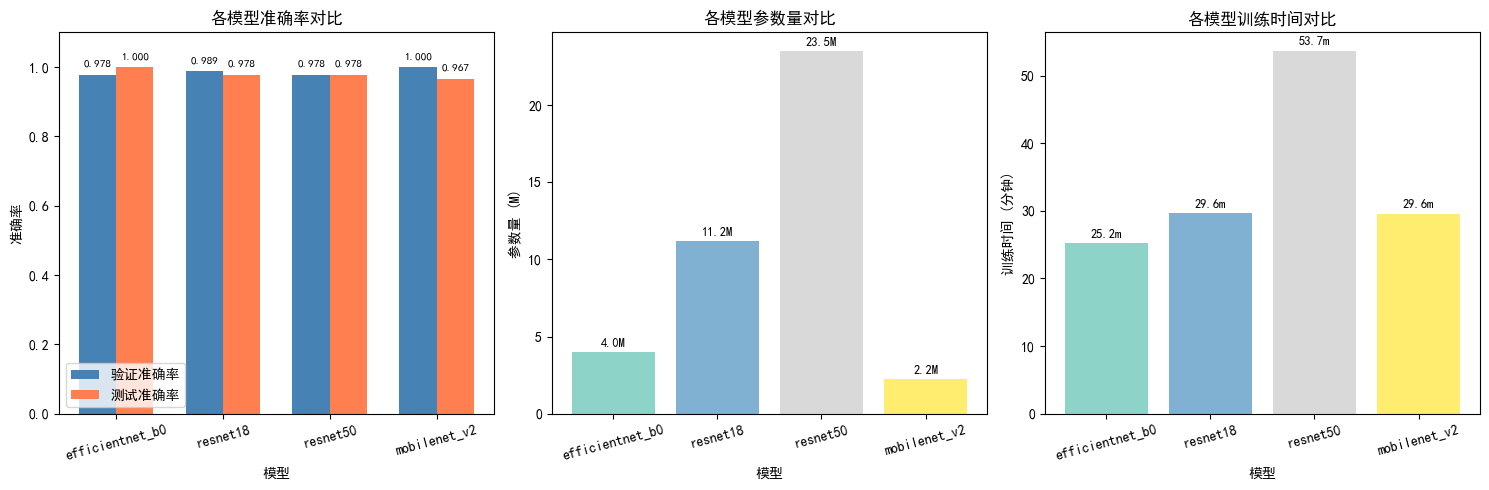


对比图已保存到 model_comparison.png


In [35]:
# 可视化对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 准确率对比
ax1 = axes[0]
x = range(len(results_df))
width = 0.35
val_accs = results_df['验证准确率'].values
test_accs = results_df['测试准确率'].values

bars1 = ax1.bar([i - width/2 for i in x], val_accs, width, label='验证准确率', color='steelblue')
bars2 = ax1.bar([i + width/2 for i in x], test_accs, width, label='测试准确率', color='coral')

ax1.set_xlabel('模型')
ax1.set_ylabel('准确率')
ax1.set_title('各模型准确率对比')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['模型'].values, rotation=15)
ax1.legend()
ax1.set_ylim([0, 1.1])

# 添加数值标签
for bar, acc in zip(bars1, val_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
for bar, acc in zip(bars2, test_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=8)

# 参数量对比
ax2 = axes[1]
params = results_df['参数量(M)'].values
colors = plt.cm.Set3(np.linspace(0, 1, len(params)))
bars = ax2.bar(x, params, color=colors)
ax2.set_xlabel('模型')
ax2.set_ylabel('参数量 (M)')
ax2.set_title('各模型参数量对比')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['模型'].values, rotation=15)

for bar, p in zip(bars, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{p:.1f}M', ha='center', va='bottom', fontsize=9)

# 训练时间对比
ax3 = axes[2]
times = results_df['训练时间(分钟)'].values
bars = ax3.bar(x, times, color=colors)
ax3.set_xlabel('模型')
ax3.set_ylabel('训练时间 (分钟)')
ax3.set_title('各模型训练时间对比')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df['模型'].values, rotation=15)

for bar, t in zip(bars, times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{t:.1f}m', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n对比图已保存到 model_comparison.png')

In [18]:
# 计算效率指标（准确率/参数量）
results_df['效率'] = results_df['测试准确率'] / results_df['参数量(M)']

print('\n模型效率分析（准确率/参数量）:')
efficiency_df = results_df[['模型', '测试准确率', '参数量(M)', '效率']].sort_values('效率', ascending=False)
print(efficiency_df.to_string(index=False))

print(f'\n效率最高的模型: {efficiency_df.iloc[0]["模型"]}')


模型效率分析（准确率/参数量）:
             模型    测试准确率    参数量(M)       效率
   mobilenet_v2 0.967033  2.230277 0.433593
efficientnet_b0 1.000000  4.013953 0.249131
       resnet18 0.978022 11.179077 0.087487
       resnet50 0.978022 23.518277 0.041586

效率最高的模型: mobilenet_v2


## 1.7 选择最佳模型进行后续实验

In [19]:
# 根据需求选择最佳模型
# 这里选择测试准确率最高的模型
best_model_name = results_df.iloc[0]['模型']
best_model = trained_models[best_model_name]

print(f'选择 {best_model_name} 作为后续实验的基础模型')
print(f'该模型测试准确率: {results_df.iloc[0]["测试准确率"]:.4f}')

# 保存最佳模型的配置
best_model_info = {
    'model_name': best_model_name,
    'test_acc': results_df.iloc[0]['测试准确率'],
    'val_acc': results_df.iloc[0]['验证准确率'],
    'params_M': results_df.iloc[0]['参数量(M)'],
    'training_time_min': results_df.iloc[0]['训练时间(分钟)']
}

print('\n第一阶段多模型对比实验完成！')

选择 efficientnet_b0 作为后续实验的基础模型
该模型测试准确率: 1.0000

第一阶段多模型对比实验完成！


# 第二阶段：YOLOv8多药材识别
## 2.1 安装YOLOv8（如果未安装）

In [20]:
# 安装ultralytics
try:
    from ultralytics import YOLO
    print('YOLOv8已安装')
except ImportError:
    print('正在安装YOLOv8...')
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics'], capture_output=True)
    from ultralytics import YOLO
    print('YOLOv8安装完成')

YOLOv8已安装


## 2.2 准备YOLO格式数据集

In [21]:
# 创建YOLO格式的数据集结构
yolo_output_dir = r'F:\药材识别\yolo_data'
yolo_train_dir = os.path.join(yolo_output_dir, 'images', 'train')
yolo_val_dir = os.path.join(yolo_output_dir, 'images', 'val')
yolo_train_labels = os.path.join(yolo_output_dir, 'labels', 'train')
yolo_val_labels = os.path.join(yolo_output_dir, 'labels', 'val')

# 创建文件夹
for folder in [yolo_train_dir, yolo_val_dir, yolo_train_labels, yolo_val_labels]:
    os.makedirs(folder, exist_ok=True)

# 创建类别映射
class_mapping = {name: idx for idx, name in enumerate(class_names)}

# 生成YOLO标签文件
def create_yolo_labels(src_dir, dst_img_dir, dst_label_dir):
    for category in class_names:
        src_cat_dir = os.path.join(src_dir, category)
        if not os.path.exists(src_cat_dir):
            continue
        
        images = [f for f in os.listdir(src_cat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_name in images:
            # 复制图片
            src_img = os.path.join(src_cat_dir, img_name)
            dst_img = os.path.join(dst_img_dir, f'{category}_{img_name}')
            shutil.copy(src_img, dst_img)
            
            # 创建标签文件（YOLO格式）
            label_name = os.path.splitext(img_name)[0] + '.txt'
            dst_label = os.path.join(dst_label_dir, f'{category}_{label_name}')
            
            with open(dst_label, 'w') as f:
                f.write(f'{class_mapping[category]} 0.5 0.5 1.0 1.0\n')

# 生成训练集和验证集标签
create_yolo_labels(train_dir, yolo_train_dir, yolo_train_labels)
create_yolo_labels(val_dir, yolo_val_dir, yolo_val_labels)

# 创建数据配置文件
yaml_content = f"""
train: {yolo_train_dir.replace('\\', '/')}
val: {yolo_val_dir.replace('\\', '/')}

nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(yolo_output_dir, 'data.yaml'), 'w', encoding='utf-8') as f:
    f.write(yaml_content)

print('YOLO数据集准备完成')
print(f'训练图片: {len(os.listdir(yolo_train_dir))}')
print(f'验证图片: {len(os.listdir(yolo_val_dir))}')

YOLO数据集准备完成
训练图片: 721
验证图片: 90


## 2.3 训练YOLOv8检测模型

In [22]:
# 使用YOLOv8 nano版本
yolo_model = YOLO('yolov8n.pt')

# 训练模型
results = yolo_model.train(
    data=os.path.join(yolo_output_dir, 'data.yaml'),
    epochs=20,
    batch=8,
    imgsz=416,
    device='cpu',
    optimizer='Adam',
    lr0=1e-3,
    weight_decay=1e-4,
    verbose=True,
    name='yolov8n_herb'
)

# 保存模型
yolo_model.save('yolov8n_herb.pt')
print('YOLOv8模型训练完成')

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.227  Python-3.12.7 torch-2.10.0+cpu CPU (Intel Core i5-8250U 1.60GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\\yolo_data\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_herb, nbs=64, nms=False, opset=No

## 2.4 YOLOv8模型验证

In [23]:
# 验证YOLO模型
val_results = yolo_model.val(data=os.path.join(yolo_output_dir, 'data.yaml'))

print('YOLO验证结果:')
print(f'mAP@0.5: {val_results.results_dict["metrics/mAP50(B)"]:.4f}')
print(f'mAP@0.5:0.95: {val_results.results_dict["metrics/mAP50-95(B)"]:.4f}')

Ultralytics 8.3.227  Python-3.12.7 torch-2.10.0+cpu CPU (Intel Core i5-8250U 1.60GHz)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 3.34.4 MB/s, size: 120.0 KB)
val: Scanning F:\药材识别\yolo_data\labels\val.cache... 90 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 90/90 49.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 0.2it/s 31.7s2.4ss
                   all         90         90      0.963      0.972      0.986      0.986
                 baihe         18         18      0.895          1      0.995      0.995
              dangshen         19         19      0.934          1       0.99       0.99
                 gouqi         18         18          1      0.972      0.995      0.995
               huaihua         17         17          1      0.887      0.955      0.955
             jinyinhua         18         18      0.9

# 第三阶段：组合识别系统
## 3.1 最佳CNN + YOLOv8 组合识别

In [24]:
# 加载最佳CNN分类模型
cnn_model = get_model(best_model_name, len(class_names), feature_extract=False)
cnn_model.load_state_dict(torch.load(f'{best_model_name}_final.pth'))
cnn_model = cnn_model.to(device)
cnn_model.eval()

# 定义图像预处理
preprocess = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 组合识别函数
def combined_recognition(image_path, conf_threshold=0.5):
    """使用YOLO检测位置，CNN精细分类"""
    results = yolo_model(image_path)
    
    image = Image.open(image_path).convert('RGB')
    final_results = []
    
    for result in results:
        boxes = result.boxes
        for box in boxes:
            confidence = float(box.conf[0].cpu().numpy())
            
            if confidence < conf_threshold:
                continue
            
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            crop = image.crop((x1, y1, x2, y2))
            
            # CNN精细分类
            input_tensor = preprocess(crop).unsqueeze(0).to(device)
            
            with torch.no_grad():
                outputs = cnn_model(input_tensor)
                _, preds = torch.max(outputs, 1)
                class_name = class_names[preds.item()]
                prob = torch.softmax(outputs, dim=1)[0][preds.item()].item()
            
            final_results.append({
                'class': class_name,
                'yolo_confidence': confidence,
                'cnn_confidence': prob,
                'bbox': (x1, y1, x2, y2)
            })
    
    return final_results

print(f'组合识别系统已准备就绪')
print(f'使用模型: YOLOv8n (检测) + {best_model_name} (分类)')

组合识别系统已准备就绪
使用模型: YOLOv8n (检测) + efficientnet_b0 (分类)


# 总结

In [25]:
print('\n' + '='*80)
print('完整药材识别系统构建完成！')
print('='*80)

print('\n【第一阶段】多模型对比实验结果:')
print(results_df.to_string(index=False))

print(f'\n最佳CNN模型: {best_model_name}')
print(f'  - 测试准确率: {best_model_info["test_acc"]:.4f}')

print('\n【第二阶段】YOLOv8检测模型:')
print(f'  - mAP@0.5: {val_results.results_dict["metrics/mAP50(B)"]:.4f}')

print('\n【第三阶段】组合识别系统:')
print(f'  - YOLOv8n (检测) + {best_model_name} (分类)')

print('\n生成的文件:')
print('  - 各模型权重: *_final.pth')
print('  - YOLO模型: yolov8n_herb.pt')
print('  - 对比图表: model_comparison.png')


完整药材识别系统构建完成！

【第一阶段】多模型对比实验结果:
             模型    参数量(M)    验证准确率    测试准确率  训练时间(分钟)       效率
efficientnet_b0  4.013953 0.977778 1.000000 25.186130 0.249131
       resnet18 11.179077 0.988889 0.978022 29.645881 0.087487
       resnet50 23.518277 0.977778 0.978022 53.684278 0.041586
   mobilenet_v2  2.230277 1.000000 0.967033 29.550761 0.433593

最佳CNN模型: efficientnet_b0
  - 测试准确率: 1.0000

【第二阶段】YOLOv8检测模型:
  - mAP@0.5: 0.9859

【第三阶段】组合识别系统:
  - YOLOv8n (检测) + efficientnet_b0 (分类)

生成的文件:
  - 各模型权重: *_final.pth
  - YOLO模型: yolov8n_herb.pt
  - 对比图表: model_comparison.png


# 图片测试与Coze API调用
## 加载模型并测试自定义图片

  药材识别与智能查询系统（EfficientNet-B0 + Coze）
原始 classifier 结构: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
EfficientNet-B0 模型加载成功！分类类别数: 5

正在识别图片: F:\药材识别\total\1.png


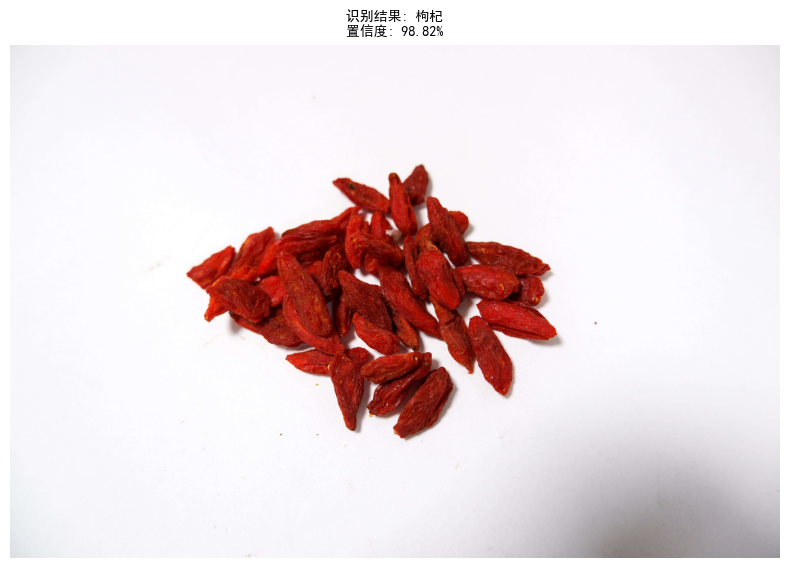


识别结果: 枸杞
置信度: 98.82%

正在向「本草小药师」查询 枸杞 的详细信息...
-------------------------------------------------------
  [1/2] 正在向 Coze 发送请求...
  [2/2] 正在接收智能体回复...

  📋 药材识别结果报告
  药材名称: 枸杞
  识别置信度: 98.82%
  图片路径: F:\药材识别\total\1.png

🌿 【枸杞】详细介绍:
-------------------------------------------------------
🌿 **枸杞** | 滋补肝肾的明目佳品

📋 **基本信息**
- 性味：味甘，性平
- 归经：肝经、肾经
- 别名：枸杞子、红耳坠、血杞子、明目子
- 产地：主产于宁夏、甘肃、青海、新疆、内蒙古等地，以宁夏中宁所产品质最佳，为道地药材

💊 **核心功效**
传统中医认为枸杞具有滋补肝肾、益精明目、润肺止咳的功效，可用于改善虚劳精亏、腰膝酸痛、眩晕耳鸣、内热消渴、血虚萎黄、目昏不明、视力减退等症状。现代药理研究表明，枸杞含枸杞多糖、甜菜碱、胡萝卜素等成分，还具有抗氧化、增强免疫、保护视神经、降血糖、抗衰老等作用。

🥣 **用法用量**
煎服，常用剂量为6～12g；日常也可泡茶、泡酒、生食或炖汤食用。

⚠️ **副作用与禁忌**
1. 脾虚便溏者慎服：枸杞有润肠作用，可能加重腹泻症状；
2. 外邪实热者忌用：感冒发热期间不宜食用；
3. 不宜过量食用：每日用量超过30g可能出现口干、流鼻血等上火症状；
4. 高血压患者在血压波动期慎用。

🔗 **想深入了解？推荐以下专业平台：**
1. 中医世家 — http://www.dazhongyi.cc/zhongyaocai/yaocai_g/gouqizi.html
2. 百度健康医典 — 可搜索“枸杞”查看专业解读
3. 用药助手 — 可搜索“枸杞”查看详细信息（该平台部分内容可能需要注册登录后查看）

💡 **趣味小贴士**
《本草纲目》记载枸杞"久服坚筋骨，轻身不老，耐寒暑"。宁夏枸杞被列为道地药材之首，有"天下枸杞出宁夏"之说。现代研究发现枸杞多糖对视网膜细胞有保护作用，印证了古人"明目"的经验。

⚕️ **温馨提示**
中药材的使用请

In [51]:
import requests
import json
import time
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# ===================== 新增这一行 =====================
from cozepy import Coze, TokenAuth, Message, ChatEventType
# =====================================================

# ============================================================
#  配置参数
# ============================================================

MODEL_PATH = 'efficientnet_b0_final.pth'
COZE_API_TOKEN = 'pat_hGdvcgMJXIa4rTWcHvUCMMDuwzq8v6inrcl29Z2ngB480UgoxJVmAoPMJvWu7kGr'
COZE_BOT_ID = '7647757490674794530'

class_names = ['百合', '党参', '枸杞', '槐花', '金银花']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# ============================================================
#  加载 EfficientNet-B0 模型
# ============================================================

def load_trained_model(model_path, num_classes, device):
    model = models.efficientnet_b0(pretrained=False)
    print(f"原始 classifier 结构: {model.classifier}")
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print(f"EfficientNet-B0 模型加载成功！分类类别数: {num_classes}")
    return model


# ============================================================
#  图片预处理
# ============================================================

test_transform = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
#  预测图片
# ============================================================

def predict_herb(image_path, model, class_names, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_class = class_names[pred_idx]
        confidence = probs[0][pred_idx].item()
    return pred_class, confidence, image


# ============================================================
#  调用 Coze 智能体
# ============================================================

def get_herb_info(herb_name):
    try:
        print(f"  [1/2] 正在向 Coze 发送请求...")

        client = Coze(
            auth=TokenAuth(token=COZE_API_TOKEN),
            base_url="https://api.coze.cn"
        )

        chat = client.chat.create(
            bot_id=COZE_BOT_ID,
            user_id="herb_user_001",
            additional_messages=[
                Message.build_user_question_text(
                    f'请介绍中药材{herb_name}的功效、用法和注意事项'
                )
            ]
        )

        print(f"  [2/2] 正在接收智能体回复...")

        full_answer = ""

        for event in client.chat.stream(
            bot_id=COZE_BOT_ID,
            user_id="herb_user_001",
            conversation_id=chat.conversation_id,
            chat_id=chat.id
        ):
            if event.event == ChatEventType.CONVERSATION_MESSAGE_DELTA:
                content = event.message.content or ""
                full_answer += content

            elif event.event == ChatEventType.CONVERSATION_CHAT_COMPLETED:
                break

        return full_answer.strip() if full_answer else "未获取到智能体回复内容"

    except Exception as e:
        return f"请求异常: {str(e)}"


# ============================================================
#  主流程
# ============================================================

if __name__ == '__main__':

    # 第一步：加载模型
    print('=' * 55)
    print('  药材识别与智能查询系统（EfficientNet-B0 + Coze）')
    print('=' * 55)

    model = load_trained_model(MODEL_PATH, len(class_names), device)

    # 第二步：预测图片
    TEST_IMAGE_PATH = r'F:\药材识别\total\1.png'

    print(f'\n正在识别图片: {TEST_IMAGE_PATH}')
    herb_name, confidence, image = predict_herb(
        TEST_IMAGE_PATH, model, class_names, device
    )

    # 第三步：显示识别结果
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(
        f'识别结果: {herb_name}\n置信度: {confidence:.2%}',
        fontsize=16,
        fontproperties='SimHei'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n识别结果: {herb_name}')
    print(f'置信度: {confidence:.2%}')

    # 第四步：置信度过低提示
    CONFIDENCE_THRESHOLD = 0.6

    if confidence < CONFIDENCE_THRESHOLD:
        print(f'\n⚠️ 置信度较低（{confidence:.2%} < {CONFIDENCE_THRESHOLD:.0%}）')
        print('图片可能不够清晰，建议重新拍摄后重试。')
        print('仍将继续查询智能体，但结果仅供参考。\n')

    # 第五步：调用 Coze 智能体
    print(f'\n正在向「本草小药师」查询 {herb_name} 的详细信息...')
    print('-' * 55)
    herb_info = get_herb_info(herb_name)

    # 第六步：输出完整结果
    print(f'\n{"=" * 55}')
    print(f'  📋 药材识别结果报告')
    print(f'{"=" * 55}')
    print(f'  药材名称: {herb_name}')
    print(f'  识别置信度: {confidence:.2%}')
    print(f'  图片路径: {TEST_IMAGE_PATH}')
    print(f'{"=" * 55}')
    print(f'\n🌿 【{herb_name}】详细介绍:')
    print(f'{"-" * 55}')
    print(herb_info)
    print(f'\n{"=" * 55}')
    print(f'⚠️ 温馨提示: 中药材使用请在专业中医师指导下进行')
    print(f'{"=" * 55}')
